In [1]:
using Pkg
Pkg.activate("./myenv")
using DelimitedFiles
using Revise
using MyPackage
using Plots
using JSON
using LaTeXStrings
using LinearAlgebra

  Activating project at `c:\Users\andre\Desktop\OpenQuantumJulia\TEDOPA\myenv`


---

In [6]:
# CHOOSE the directory with measurements data
dir_path = "./runs/2025-03-04_18-13-50"
# create the directory to store figures if it doesn't exist
figs_path = dir_path * "/figs"
mkpath(figs_path)
# read config file
config_path = dir_path * "/config.JSON"
config = load_config(config_path) 

(α = 0.1, ωc = 1.0, T = 0.2, ϵ = 0.0, Δ = 0.2, dt = 0.01, tmax = 30, growMPSval = 10, chain_size = 250, local_dim = 6, sdf_eq = "pi/2 * a[1] * x * a[2]^2 / ( x^2 + a[2]^2 )")

---

In [5]:
# pauli basis
σ0, σ1, σ2, σ3 = pauli;
# computational basis
T00, T01, T10, T11 = T;

---

## Spectral density function and its tedopa coefficients

In [8]:
# sdf
sdf_filename = "debye_a_0.1_T_0.2.json"
# open and read the JSON file
input = open(sdf_filename)
s = read(input, String)
# parsing JSON data: parse the string s as a JSON object and assigns the resulting dictionary-like structure to p
p = JSON.parse(s)
# extracting parameters
a =  Float64.(p["environment"]["spectral_density_parameters"])
support = Float64.(p["environment"]["domain"])
# retrieves a string representing the spectral density function formula
fn = p["environment"]["spectral_density_function"]
# creating a callable function object tmp
tmp = eval(Meta.parse("(a, x) -> " * fn))
# defining a function sdf of one variable x. Calls the dynamically created function tmp
sdf = x -> Base.invokelatest(tmp, a, x)
# creating an ohmic spectral density function
jOhmic(ω) = sdf(ω)

jOhmic (generic function with 1 method)

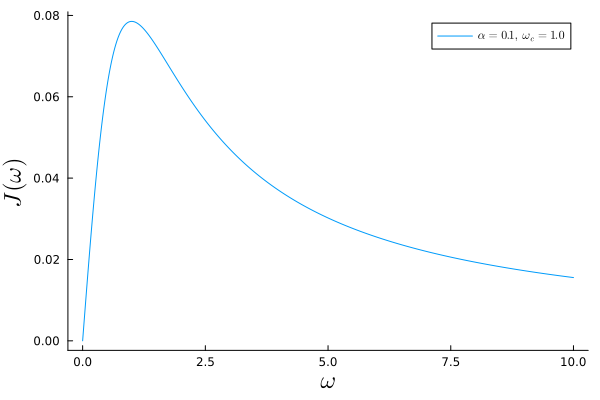

In [9]:
# plot the spectral density function
xs = collect(range(support...,1000))
ys = jOhmic.(xs)
# Create and display the plot
p = plot(xs, ys, label=L"\alpha=%$(config.α),\,\omega_c=%$(config.ωc)",
    xlabel=L"\omega", ylabel=L"J(\omega)",
    xlabelfontsize=16, ylabelfontsize=16,
    grid=false
)
display(p)

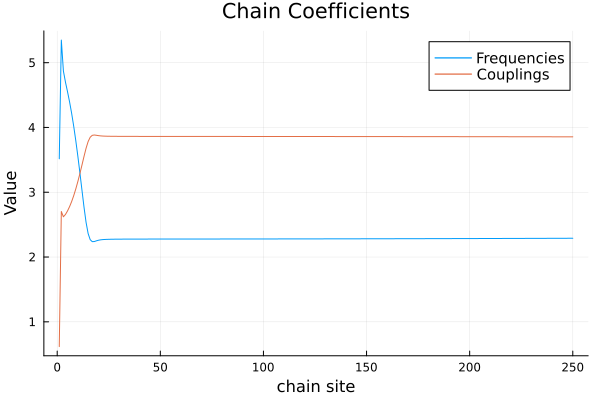

"c:\\Users\\andre\\Desktop\\OpenQuantumJulia\\TEDOPA\\runs\\2025-03-04_18-13-50\\figs\\chain_coefficients.png"

In [11]:
# Compute coefficients
coefficients = config.T == 0 ? MyPackage.TEDOPA.chainmapping_tedopa(sdf_filename) : MyPackage.TEDOPA.chainmapping_ttedopa(sdf_filename)

# Prepare data
freqs_x = collect(1:length(coefficients.frequencies))
coups_x = collect(1:length(coefficients.couplings))

# Create the plot
p = plot(freqs_x, coefficients.frequencies, label="Frequencies")
plot!(coups_x, coefficients.couplings, label="Couplings")

# Formatting
plot!(title="Chain Coefficients", legendfontsize=10, xlabel="chain site", ylabel="Value")

# Display the plot
display(p)

# Save the figure
savefig(figs_path * "/chain_coefficients.png")

## Equivalent way to see time evolutions (check)
I described different perspectives on the way to see time evolution of a state, check that are all equivalent. Remember that all of them followed from map tomography performed using TDVP1.
- Quantum map (map): 
$$\rho(t) = \mathcal{E}_t \rho_0$$

- Master equation (me): 
$$\frac{d}{dt} \rho(t) = \mathcal{L}_t \rho(t)$$

- Kraus decomposition of $\mathcal{L}_t$ (kd): 
$$ \frac{d}{dt} \rho(t) = \sum_k \lambda_k(t) E_k(t) \rho(t) E_k(t)^{\dagger}$$

I verify the consistency of these methods taking as benchmark the time evolution of the state "Up" with TDVP1.

In [25]:
# matrix to vector
function matrix2vector(mat::Matrix{Complex{Float64}}, basis)
    vec = Complex{Float64}[]
    for elem in basis
        push!(vec, 0.5 * tr(mat'*elem)) # ATT! 0.5 * tr(A' * B) inner product for pauli basis to be orthonormal
    end
    vec
end

# vector to matrix
function vector2matrix(vec::Vector{Complex{Float64}}, basis)
    sum(vec .* basis)
end

vector2matrix (generic function with 1 method)

In [26]:
function kraus_term(kraus_operator, eigvals, state)
    sum([ eigvals[k] * kraus_operator[k] * state * kraus_operator[k]' for k in 1:size(eigvals, 1) ])
end

kraus_term (generic function with 1 method)

In [29]:
# state Up 
up = Complex{Float64}[1.0 0.0; 0.0 0.0]

# TDVP1
evolvedUp = MyPackage.get_evolved_states(dir_path * "/measurements_Up.dat")

# QUANTUM MAP
myMap = quantum_map(dir_path)
vec_evolved_map = Vector{Vector{Complex{Float64}}}()
for i in 1:size(myMap)[1]
   push!(vec_evolved_map, myMap[i,:,:] * matrix2vector(up, pauli))
end
evolved_map = map(x->vector2matrix(x, pauli), vec_evolved_map);

# MASTER EQUATION
myGen = generator(myMap, config.dt)
vec_evolved_me = Vector{Vector{Complex{Float64}}}()
push!(vec_evolved_me, matrix2vector(up, pauli))
for i in 1:size(myGen)[1]
    push!(vec_evolved_me, vec_evolved_me[i] + config.dt * myGen[i] * vec_evolved_me[i]) # eulero integration
end
evolved_me = map(x->vector2matrix(x, pauli), vec_evolved_me);

# KRAUS DECOMPOSITION
choi_eigvals, EE = kraus_decomposition(myGen)
evolved_kd = Vector{Matrix{ComplexF64}}()
push!(evolved_kd, up)
for t in 1:size(choi_eigvals, 1)
    push!(evolved_kd, evolved_kd[t] + config.dt * kraus_term(EE[t], choi_eigvals[t], evolved_kd[t]))
end

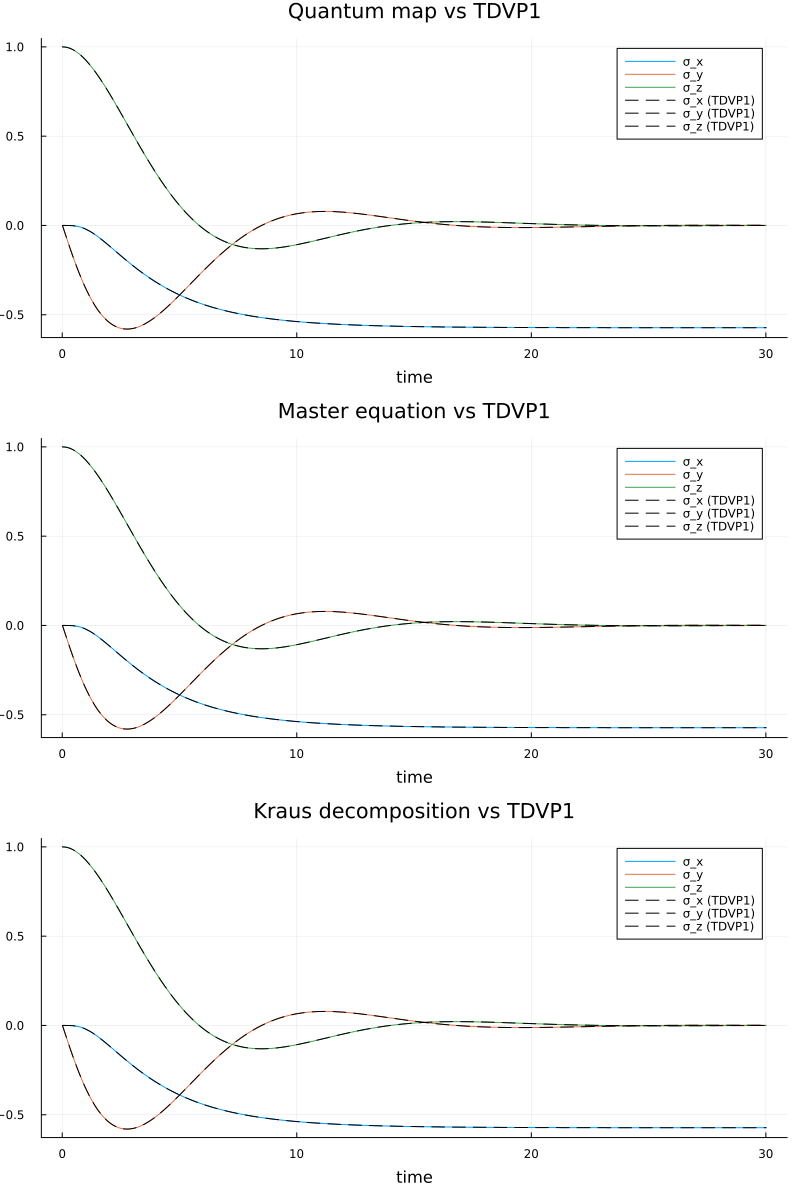

In [30]:
function compare_TDVP1(tdvp_data, data, title)
    plt = plot(config.dt*collect(1:length(data)), real(map(x -> tr(σ1 * x), data)), label="σ_x", size=(800, 500))
    plot!(config.dt*collect(1:length(data)), real(map(x -> tr(σ2 * x), data)), label="σ_y")
    plot!(config.dt*collect(1:length(data)), real(map(x -> tr(σ3 * x), data)), label="σ_z")
    plot!(config.dt*collect(1:length(tdvp_data)), real(map(x -> tr(σ1 * x), tdvp_data)), label="σ_x (TDVP1)", linestyle=:dash, color=:black)
    plot!(config.dt*collect(1:length(tdvp_data)), real(map(x -> tr(σ2 * x), tdvp_data)), label="σ_y (TDVP1)", linestyle=:dash, color=:black)
    plot!(config.dt*collect(1:length(tdvp_data)), real(map(x -> tr(σ3 * x), tdvp_data)), label="σ_z (TDVP1)", linestyle=:dash, color=:black)
    plot!(title=title, xlabel="time")
    return plt
end

p1 = compare_TDVP1(evolvedUp, evolved_map, "Quantum map vs TDVP1")
p2 = compare_TDVP1(evolvedUp, evolved_me, "Master equation vs TDVP1")
p3 = compare_TDVP1(evolvedUp, evolved_kd, "Kraus decomposition vs TDVP1")

display(plot(p1, p2, p3, layout=(3,1), size=(800, 1200)))

## Equivalent way to see effective hamiltonian $K_s(t)$ (check)

From the Kraus decomposition of the generator the effective hamiltonian of the system is 
$$ K_s(t) = - \frac{i}{4} \sum_k \lambda_k(t) \left[ \text{Tr}[E_k(t)] E_k^{\dagger}(t) - \text{Tr}[E_k^{\dagger}(t)] E_k(t) \right]. $$

An equivalent way to obtain this result is using the following equation
$$ K_s(t) = - \frac{i}{4} \sum_\alpha \Big[F_\alpha\,,\, \mathcal{L}_t[F_\alpha] \Big] $$
where $F_\alpha$ is an orthonormal base for $\mathcal{L}(\mathcal{H})$.

In [31]:
Ks = effective_hamiltonian(dir_path);

In [32]:
Ks_check = Vector{Matrix{ComplexF64}}()
# push iniziale con Ks al tempo zero?
for t in 1:size(EE, 1)
    push!(Ks_check, -im/4. * sum([ 
                T[a]' * kraus_term(EE[t], choi_eigvals[t], T[a]) -
                kraus_term(EE[t], choi_eigvals[t], T[a]) * T[a]' 
                for a in 1:size(T,1) ]))
end

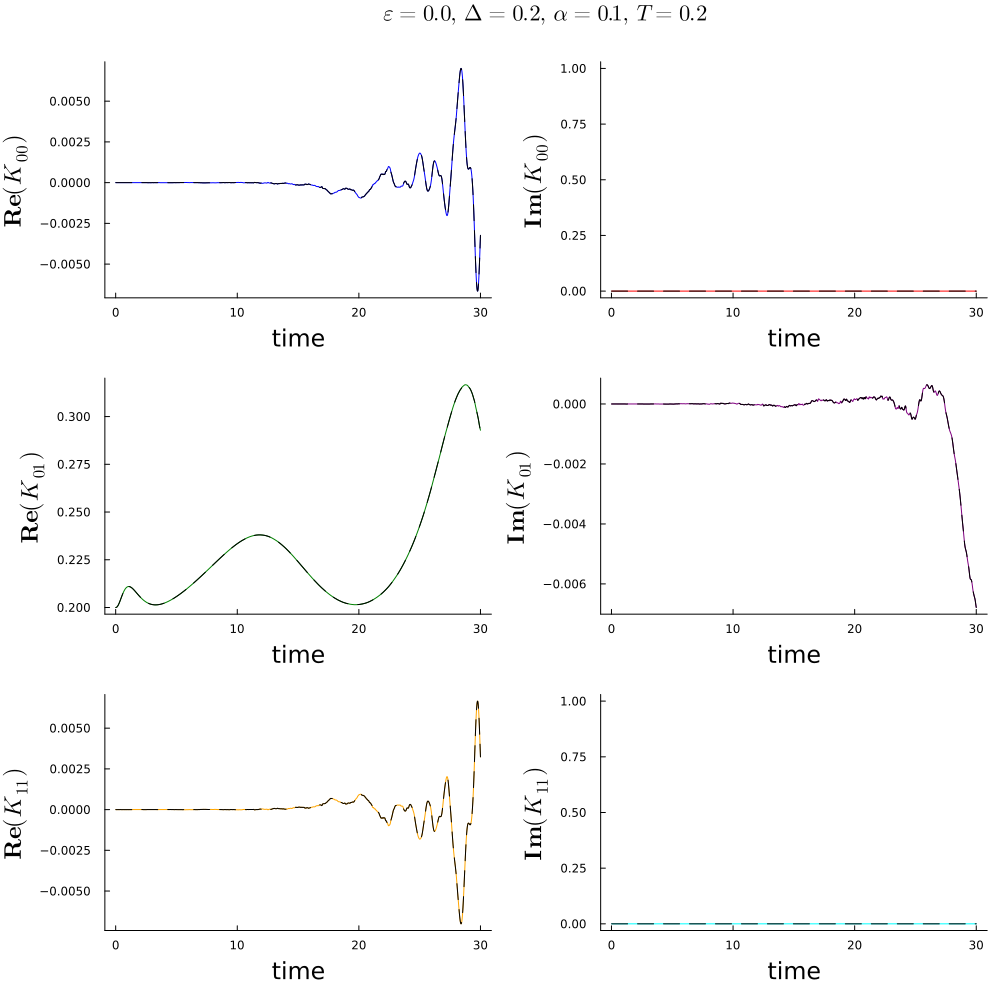

In [35]:
# Generate the subplots for real and imaginary parts of Ks
xs = config.dt * collect(1:length(Ks))

# p1 - Real part of K_00
p1 = plot(xs, [real(Ks[t][1,1]) for t in 1:length(Ks)], label=L"\textbf{Re}(K_{00})", lc=:blue)
plot!(p1, xlabel="time", ylabel=L"\textbf{Re}(K_{00})", xlabelfontsize=16, ylabelfontsize=16, grid=false, legend=false)
plot!(p1, xs, [real(Ks_check[t][1,1]) for t in 1:length(Ks_check)], label="Ks_check", linestyle=:dash, color=:black)

# p2 - Imaginary part of K_00
p2 = plot(xs, [imag(Ks[t][1,1]) for t in 1:length(Ks)], label=L"\textbf{Im}(K_{00})", lc=:red)
plot!(p2, xlabel="time", ylabel=L"\textbf{Im}(K_{00})", xlabelfontsize=16, ylabelfontsize=16, grid=false, legend=false)
plot!(p2, xs, [imag(Ks_check[t][1,1]) for t in 1:length(Ks_check)], label="Ks_check", linestyle=:dash, color=:black)

# p3 - Real part of K_01
p3 = plot(xs, [real(Ks[t][1,2]) for t in 1:length(Ks)], label=L"\textbf{Re}(K_{01})", lc=:green)
plot!(p3, xlabel="time", ylabel=L"\textbf{Re}(K_{01})", xlabelfontsize=16, ylabelfontsize=16, grid=false, legend=false)
plot!(p3, xs, [real(Ks_check[t][1,2]) for t in 1:length(Ks_check)], label="Ks_check", linestyle=:dash, color=:black)

# p4 - Imaginary part of K_01
p4 = plot(xs, [imag(Ks[t][1,2]) for t in 1:length(Ks)], label=L"\textbf{Im}(K_{01})", lc=:purple)
plot!(p4, xlabel="time", ylabel=L"\textbf{Im}(K_{01})", xlabelfontsize=16, ylabelfontsize=16, grid=false, legend=false)
plot!(p4, xs, [imag(Ks_check[t][1,2]) for t in 1:length(Ks_check)], label="Ks_check", linestyle=:dash, color=:black)

# p5 - Real part of K_11
p5 = plot(xs, [real(Ks[t][2,2]) for t in 1:length(Ks)], label=L"\textbf{Re}(K_{11})", lc=:orange)
plot!(p5, xlabel="time", ylabel=L"\textbf{Re}(K_{11})", xlabelfontsize=16, ylabelfontsize=16, grid=false, legend=false)
plot!(p5, xs, [real(Ks_check[t][2,2]) for t in 1:length(Ks_check)], label="Ks_check", linestyle=:dash, color=:black)

# p6 - Imaginary part of K_11
p6 = plot(xs, [imag(Ks[t][2,2]) for t in 1:length(Ks)], label=L"\textbf{Im}(K_{11})", lc=:cyan)
plot!(p6, xlabel="time", ylabel=L"\textbf{Im}(K_{11})", xlabelfontsize=16, ylabelfontsize=16, grid=false, legend=false)
plot!(p6, xs, [imag(Ks_check[t][2,2]) for t in 1:length(Ks_check)], label="Ks_check", linestyle=:dash, color=:black)

# Combine the subplots into a single layout
final_plot = plot(p1, p2, p3, p4, p5, p6, 
    layout=(3, 2), size=(1000, 1000), 
    plot_title=L"\epsilon=%$(config.ϵ),\,\Delta=%$(config.Δ),\,\alpha=%$(config.α),\,T=%$(config.T)", 
    plot_titlefontsize=15)

# Save the figure
savefig(figs_path * "/Ks_chack.png")

# Display the final plot
display(final_plot)
